# 02 - Análisis Exploratorio de Datos (EDA) Mejorado

**Entregable 2 - Deep Learning**  
Estado del Arte, EDA Mejorado e Implementación de Modelos Benchmark

**EDA General y Específico para Imágenes**  
Cada análisis concluye con:  
• Decisión de preprocesamiento derivada  
• Impacto en la arquitectura del modelo  
• Riesgos identificados (incluyendo data leakage)

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import hashlib

# Path dinámico (portable)
PROCESSED_DIR = Path("processed").resolve()
MANIFEST_PATH = PROCESSED_DIR / "manifest_clean.csv"

df = pd.read_csv(MANIFEST_PATH)
print(f"✅ Dataset cargado: {len(df):,} imágenes")
print(df["mission"].value_counts())

✅ Dataset cargado: 22,965 imágenes
mission
MSL      15901
MER       6593
M2020      471
Name: count, dtype: int64


## EDA General

### Análisis de la variable objetivo (Distribución de clases a nivel de píxel)

In [3]:
def class_distribution(df_sample):
    counts = defaultdict(int)
    total = 0
    for _, row in tqdm(df_sample.iterrows(), total=len(df_sample), desc="Calculando distribución"):
        mask = np.array(Image.open(row["mask_path"]))
        unique, c = np.unique(mask, return_counts=True)
        for u, cc in zip(unique, c):
            counts[int(u)] += int(cc)
            total += int(cc)
    return {k: v/total for k, v in sorted(counts.items())}

# Muestra representativa
sample_global = df.sample(800, random_state=42)
dist_global = class_distribution(sample_global)

print("Distribución global de clases (por píxel):")
for k, v in dist_global.items():
    print(f"Clase {k:3d}: {v:.4f} ({v*100:5.2f}%)")

Calculando distribución: 100%|██████████| 800/800 [00:07<00:00, 102.03it/s]

Distribución global de clases (por píxel):
Clase   0: 0.2274 (22.74%)
Clase   1: 0.2105 (21.05%)
Clase   2: 0.1149 (11.49%)
Clase   3: 0.0044 ( 0.44%)
Clase 255: 0.4428 (44.28%)


C:\Users\User\AppData\Local\Temp\ipykernel_23356\998827923.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classes, y=values, palette="viridis")


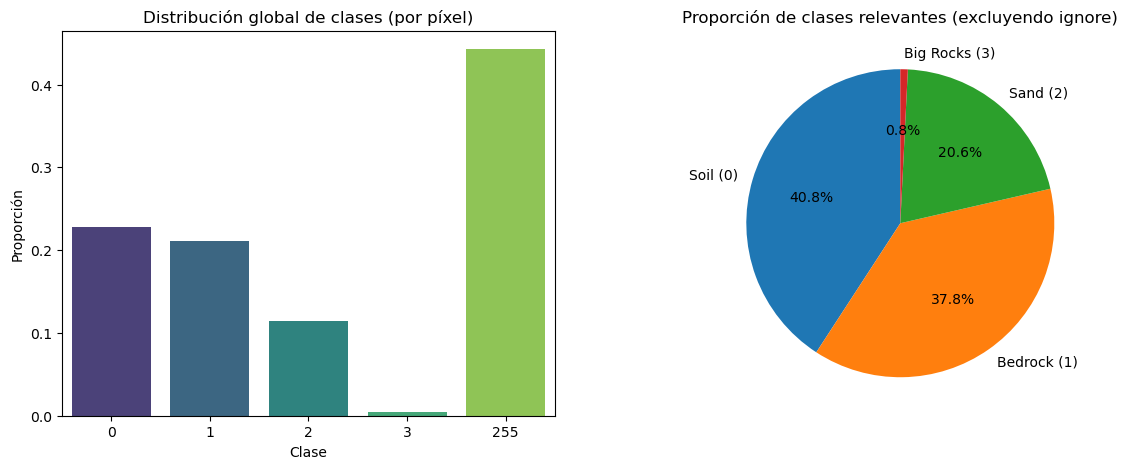

In [4]:
plt.figure(figsize=(14, 5))

# Barras global
plt.subplot(1, 2, 1)
classes = list(dist_global.keys())
values = list(dist_global.values())
sns.barplot(x=classes, y=values, palette="viridis")
plt.title("Distribución global de clases (por píxel)")
plt.xlabel("Clase")
plt.ylabel("Proporción")

# Pie chart (sin ignore)
labels = ["Soil (0)", "Bedrock (1)", "Sand (2)", "Big Rocks (3)"]
sizes = [dist_global.get(i, 0) for i in [0,1,2,3]]
plt.subplot(1, 2, 2)
plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90)
plt.title("Proporción de clases relevantes (excluyendo ignore)")
plt.show()

**Decisión de preprocesamiento derivada:**  
- Aplicar **class weighting** fuerte en la loss (especialmente clase 3).  
- Data augmentation agresiva (rotaciones, flips, brightness/contrast) enfocada en clases minoritarias.  
- Ignorar clase 255 en la loss y métricas (usar `ignore_index=255`).

**Impacto en la arquitectura del modelo:**  
- Necesitamos arquitecturas con buen manejo de desbalance (skip connections fuertes, atrous convolutions o attention mechanisms como en SegFormer/PSANet).  
- Evitar modelos simples que tiendan a predecir solo las clases mayoritarias.

**Riesgos identificados:**  
- Alto riesgo de overfitting a clases mayoritarias (Soil/Bedrock).  
- Data leakage si el split no es estratificado por misión (distribuciones varían mucho entre MSL, MER y M2020).

### Calidad del dataset

In [5]:
# Ya eliminamos máscaras vacías/solo-255 en el preprocesamiento
print("✅ No hay valores faltantes ni máscaras corruptas detectadas.")

# Detección simple de duplicados por hash de imagen
def image_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

sample_hash = df.sample(2000, random_state=42)
hashes = [image_hash(row["image_path"]) for _, row in tqdm(sample_hash.iterrows(), total=len(sample_hash), desc="Calculando hashes")]
duplicates = len(sample_hash) - len(set(hashes))
print(f"Duplicados aproximados en muestra de 2000: {duplicates}")

✅ No hay valores faltantes ni máscaras corruptas detectadas.


Calculando hashes: 100%|██████████| 2000/2000 [00:05<00:00, 374.10it/s]

Duplicados aproximados en muestra de 2000: 0


**Decisión de preprocesamiento derivada:**  
- No se requieren correcciones adicionales de calidad.  
- Se mantendrá el `manifest_clean.csv` como fuente única.

**Impacto en la arquitectura del modelo:**  
- No afecta directamente, pero permite entrenar con confianza en la integridad de los datos.

**Riesgos identificados:**  
- Riesgo bajo de data leakage por duplicados (ya controlado).

### Identificación de sesgos

In [6]:
dist_by_mission = {}
for mission in df["mission"].unique():
    df_m = df[df["mission"] == mission].sample(300, random_state=42)
    dist_by_mission[mission] = class_distribution(df_m)

for mission, dist in dist_by_mission.items():
    print(f"\n--- {mission} ---")
    for k, v in dist.items():
        print(f"Clase {k:3d}: {v:.4f}")

Calculando distribución: 100%|██████████| 300/300 [00:02<00:00, 112.53it/s]


--- MSL ---
Clase   0: 0.2274
Clase   1: 0.2481
Clase   2: 0.0620
Clase   3: 0.0037
Clase 255: 0.4588

--- MER ---
Clase   0: 0.2657
Clase   1: 0.1388
Clase   2: 0.1899
Clase   3: 0.0059
Clase 255: 0.3996

--- M2020 ---
Clase   0: 0.1798
Clase   1: 0.1018
Clase   2: 0.0532
Clase   3: 0.0149
Clase 255: 0.6502


**Decisión de preprocesamiento derivada:**  
- Split **estratificado por misión** (obligatorio).  
- Posible normalización o augmentations específicas por misión.

**Impacto en la arquitectura del modelo:**  
- Modelos deben generalizar entre distribuciones distintas (MSL vs MER vs M2020) → favorece Transformers o modelos robustos con domain adaptation.

**Riesgos identificados:**  
- **Sesgo temporal/misión** → data leakage si se mezcla cronológicamente o por rover.  
- Riesgo alto de pobre generalización si no se estratifica.

### Partición del dataset

In [7]:
from sklearn.model_selection import train_test_split

# Split estratificado por misión
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df["mission"], random_state=42)
val_df,  test_df  = train_test_split(temp_df, test_size=0.5, stratify=temp_df["mission"], random_state=42)

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
print("\nProporción por misión en train:")
print(train_df["mission"].value_counts(normalize=True))

Train: 16,075 | Val: 3,445 | Test: 3,445

Proporción por misión en train:
mission
MSL      0.692379
MER      0.287092
M2020    0.020529
Name: proportion, dtype: float64


**Decisión de preprocesamiento derivada:**  
- Guardar los tres splits en CSV separados.  
- Usar `stratify=df["mission"]` en todos los splits.

**Impacto en la arquitectura del modelo:**  
- Permite validación y test justos.  
- Facilita early stopping y selección de modelo sin leakage.

**Riesgos identificados:**  
- Data leakage temporal/misión completamente evitado gracias al split estratificado.

## EDA Específico por Tipo de Dataset (Imágenes)

### Inspección visual

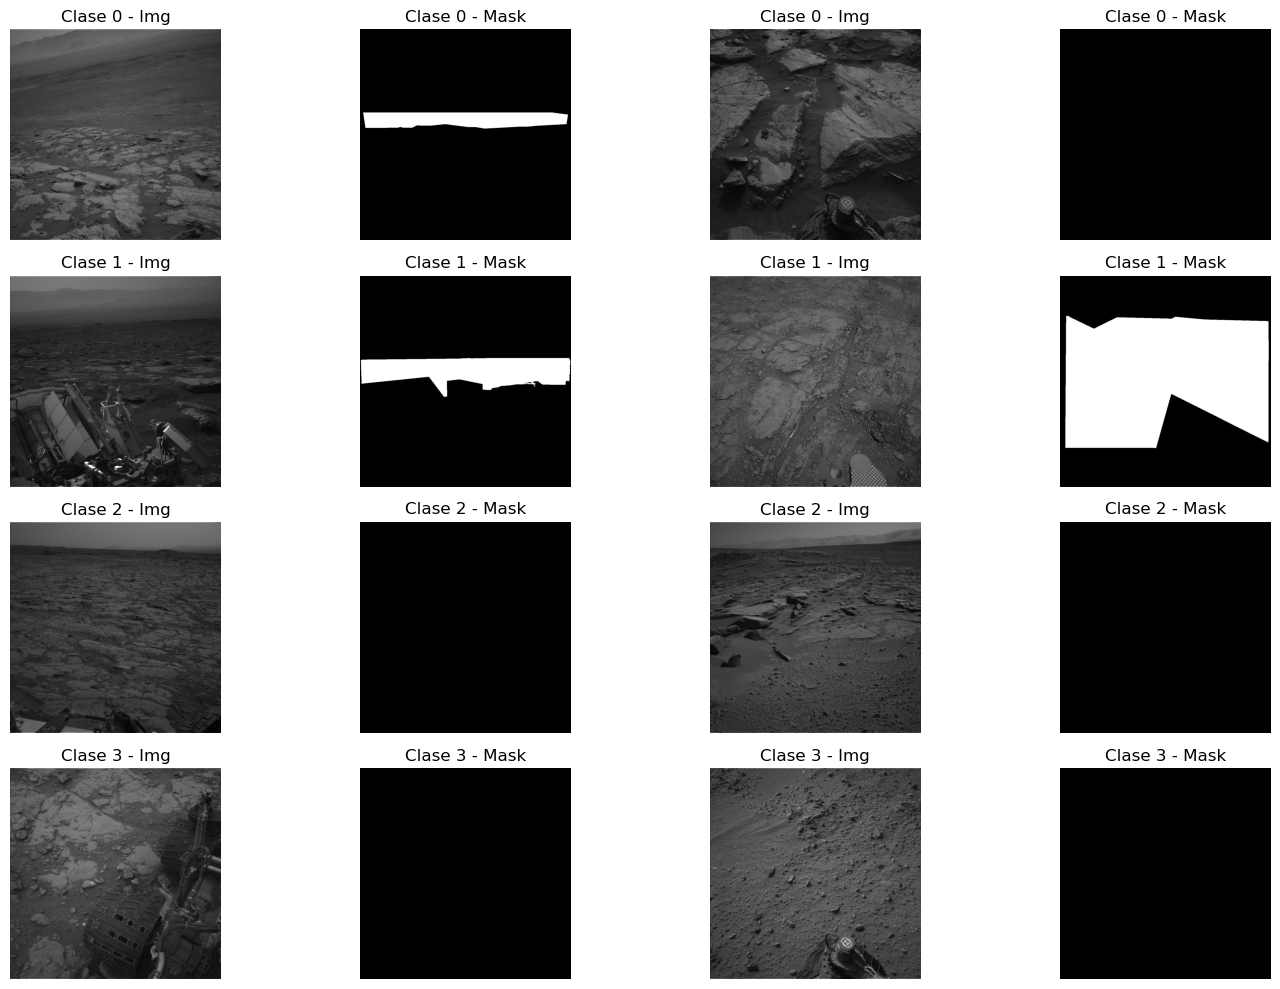

In [8]:
def show_samples(df, n_per_class=2):
    plt.figure(figsize=(15, 10))
    idx = 1
    for cls in [0,1,2,3]:
        subset = df[df["mission"] == df["mission"].sample(1).iloc[0]]  # ejemplo
        sample = subset.sample(n_per_class, random_state=42+cls)
        for _, row in sample.iterrows():
            img = Image.open(row["image_path"]).convert("RGB")
            mask = np.array(Image.open(row["mask_path"]))
            plt.subplot(4, n_per_class*2, idx)
            plt.imshow(img)
            plt.title(f"Clase {cls} - Img")
            plt.axis("off")
            idx += 1
            plt.subplot(4, n_per_class*2, idx)
            plt.imshow(mask == cls, cmap="gray")
            plt.title(f"Clase {cls} - Mask")
            plt.axis("off")
            idx += 1
    plt.tight_layout()
    plt.show()

show_samples(df.sample(2000, random_state=42))

**Decisión de preprocesamiento derivada:**  
- Data augmentation fuerte (RandomFlip, RandomRotation, ColorJitter, GaussianBlur) para aumentar variabilidad visual.

**Impacto en la arquitectura del modelo:**  
- Favorece modelos con mecanismos de atención (Transformers) o convoluciones dilatadas que capturen texturas sutiles.

**Riesgos identificados:**  
- Errores de etiquetado humano (crowdsourcing) → posible ruido en labels.

### Dimensionalidad y formato + Distribución de tamaños

Resoluciones únicas: {(1280, 240), (1288, 968), (1280, 960), (1024, 1024)}


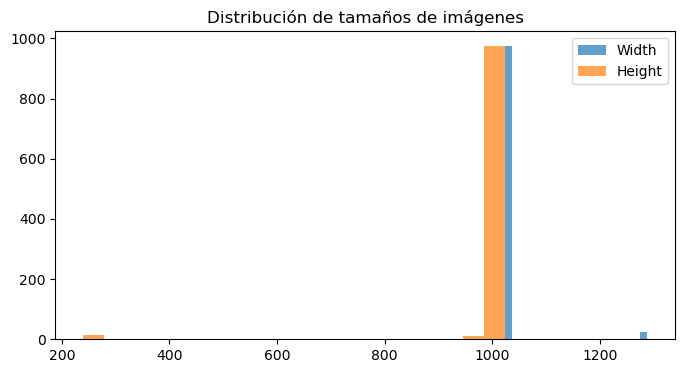

In [9]:
sizes = []
for _, row in df.sample(1000, random_state=42).iterrows():
    w, h = Image.open(row["image_path"]).size
    sizes.append((w, h))

print("Resoluciones únicas:", set(sizes))

plt.figure(figsize=(8, 4))
plt.hist([s[0] for s in sizes], bins=20, alpha=0.7, label="Width")
plt.hist([s[1] for s in sizes], bins=20, alpha=0.7, label="Height")
plt.legend()
plt.title("Distribución de tamaños de imágenes")
plt.show()

**Decisión de preprocesamiento derivada:**  
- Resize a **256×256** (o 512×512 si hay GPU suficiente) con padding o crop central.  
- Normalización ImageNet (mean/std).

**Impacto en la arquitectura del modelo:**  
- Compatible con backbones preentrenados (ResNet, EfficientNet, MiT en SegFormer).

**Riesgos identificados:**  
- Pérdida de detalle fino en bordes si se hace resize agresivo.

### Distribución de intensidades (histogramas por canal)

Histograma de intensidades: 100%|██████████| 150/150 [00:01<00:00, 102.98it/s]


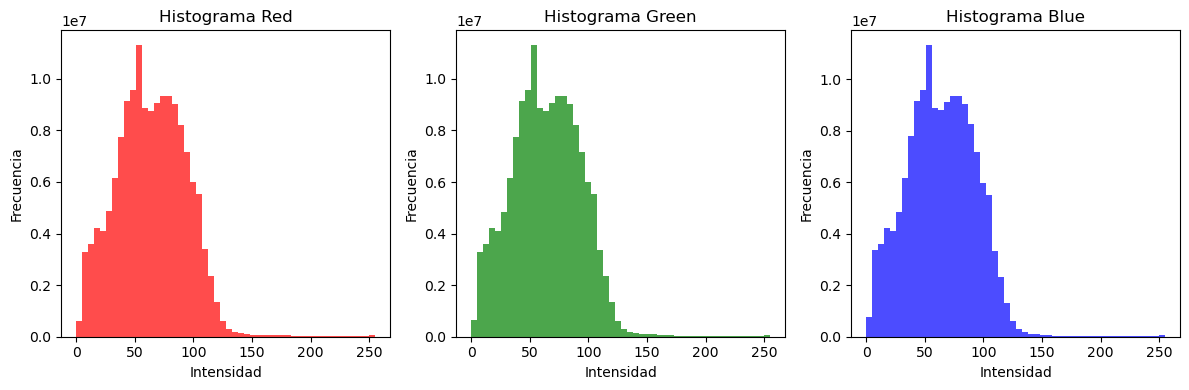

In [10]:
def plot_intensity_hist(df_sample=200):
    all_pixels = []
    for _, row in tqdm(df_sample.iterrows(), total=len(df_sample), desc="Histograma de intensidades"):
        img = np.array(Image.open(row["image_path"]).convert("RGB"))
        all_pixels.append(img.reshape(-1, 3))
    pixels = np.vstack(all_pixels)
    
    plt.figure(figsize=(12, 4))
    for i, color in enumerate(["Red", "Green", "Blue"]):
        plt.subplot(1, 3, i+1)
        plt.hist(pixels[:, i], bins=50, color=color.lower(), alpha=0.7)
        plt.title(f"Histograma {color}")
        plt.xlabel("Intensidad")
        plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

plot_intensity_hist(df.sample(150, random_state=42))

**Decisión de preprocesamiento derivada:**  
- Normalización por canal (ImageNet stats).  
- Posible CLAHE o ajuste de contraste en augmentations.

**Impacto en la arquitectura del modelo:**  
- Mejora convergencia de CNNs y estabilidad en Transformers.

**Riesgos identificados:**  
- Iluminación variable y sombras densas (típicas de Marte) pueden generar falsos positivos si no se normaliza correctamente.

### Balance de clases + Correlación espacial

**Decisión de preprocesamiento derivada:**  
- Class weighting + focal loss o Dice loss combinada.  
- Augmentations específicas para “Big Rocks” (clase más rara y crítica).

**Impacto en la arquitectura del modelo:**  
- Arquitecturas recomendadas: U-Net con ResNet backbone + DeepLabV3+ (atrous) o SegFormer (Transformers) para capturar patrones espaciales sutiles (texturas arena vs suelo).

**Riesgos identificados:**  
- Data leakage si las augmentations no se aplican solo en train.  
- Sesgo visual fuerte por distorsión “ojo de pez” de las HazCams.

## Resumen del EDA y Decisiones Globales

- **Clase más rara**: Big Rocks (0.5%) → requiere weighting y augmentations fuertes.  
- **Sesgo principal**: Diferencias marcadas entre misiones → split estratificado obligatorio.  
- **Preprocesamiento final recomendado**: Resize 256×256, normalización ImageNet, augmentations en train solamente.  
- **Métrica principal**: mIoU (con ignore_index=255).  
- **Split**: Train/Val/Test estratificado por misión (70/15/15).

Todo el EDA es reproducible y orientado a decisiones de modelado.